In [ ]:
!pip install "qiskit==1.*" "qiskit-machine-learning==0.7.*" ipywidgets
!pip install qiskit
!pip install qiskit qiskit-aer matplotlib pylatexenc


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Quantum
try:
    from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap
    from qiskit_machine_learning.kernels import FidelityStatevectorKernel
    QISKIT_OK = True
except Exception:
    QISKIT_OK = False
    print("Qiskit ML not available. Install per setup cell to run QSVM.")

# Widgets
try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown
    WIDGETS_OK = True
except Exception:
    WIDGETS_OK = False
    print("ipywidgets not available; interactivity limited.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def plot_confusion_matrix(cm, title):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0,1], ["malignant","benign"], rotation=45)
    plt.yticks([0,1], ["malignant","benign"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j,i,str(v), ha="center", va="center")
    plt.tight_layout()
    plt.show()

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target  # 0=malignant, 1=benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print("Train/Test shapes:", X_train.shape, X_test.shape)
print("Classes: malignant=0, benign=1")
print("Feature names (first 5):", data.feature_names[:5])

Train/Test shapes: (398, 30) (171, 30)
Classes: malignant=0, benign=1
Feature names (first 5): ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [ ]:
USE_PCA = True
PCA_COMPONENTS = 4

steps = [("scaler", StandardScaler())]
if USE_PCA:
    steps.append(("pca", PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)))
feature_pipe = Pipeline(steps)

X_train_t = feature_pipe.fit_transform(X_train)
X_test_t  = feature_pipe.transform(X_test)

print("Transformed shapes:", X_train_t.shape, X_test_t.shape)

Transformed shapes: (398, 4) (171, 4)


In [ ]:
if WIDGETS_OK:
    comp_slider = widgets.IntSlider(value=4, min=2, max=10, step=1, description='PCA comps')
    use_pca = widgets.Checkbox(value=True, description='Use PCA?')
    display(Markdown("**Try me:** Adjust PCA components and toggle PCA, then re-run the previous cell to apply."))
    display(use_pca, comp_slider)

**Try me:** Adjust PCA components and toggle PCA, then re-run the previous cell to apply.

Checkbox(value=True, description='Use PCA?')

IntSlider(value=4, description='PCA comps', max=10, min=2)

Linear SVM -> Acc: 0.9415 | Prec: 0.9802 | Rec: 0.9252
RBF SVM  -> Acc: 0.9591 | Prec: 0.9545 | Rec: 0.9813


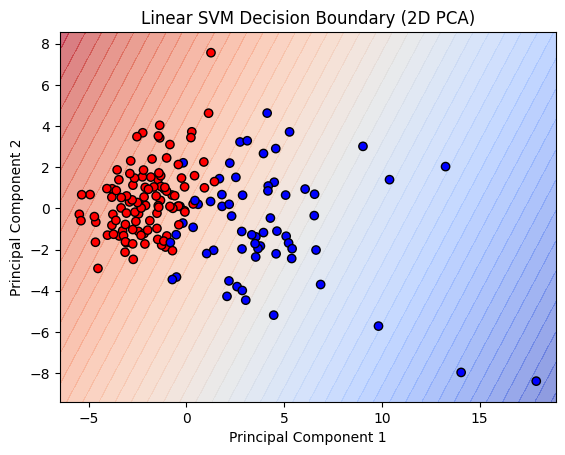

In [ ]:
# svm_linear = SVC(kernel="linear", random_state=RANDOM_STATE)
# svm_rbf    = SVC(kernel="rbf", gamma="scale", C=1.0, random_state=RANDOM_STATE)

# svm_linear.fit(X_train_t, y_train)
# svm_rbf.fit(X_train_t, y_train)

# y_lin = svm_linear.predict(X_test_t)
# y_rbf = svm_rbf.predict(X_test_t)

# def metrics(y_true, y_pred):
#     return accuracy_score(y_true,y_pred), precision_score(y_true,y_pred), recall_score(y_true,y_pred), confusion_matrix(y_true,y_pred)

# acc_l, prec_l, rec_l, cm_l = metrics(y_test, y_lin)
# acc_r, prec_r, rec_r, cm_r = metrics(y_test, y_rbf)

# print("Linear SVM -> Acc: %.4f | Prec: %.4f | Rec: %.4f" % (acc_l, prec_l, rec_l))
# plot_confusion_matrix(cm_l, "Linear SVM – Confusion Matrix")

# print("RBF SVM  -> Acc: %.4f | Prec: %.4f | Rec: %.4f" % (acc_r, prec_r, rec_r))
# plot_confusion_matrix(cm_r, "RBF SVM – Confusion Matrix")




from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Reduce features to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_t)
X_test_2d  = pca.transform(X_test_t)

# Train SVMs on 2D data
svm_linear = SVC(kernel="linear", random_state=RANDOM_STATE)
svm_rbf    = SVC(kernel="rbf", gamma="scale", C=1.0, random_state=RANDOM_STATE)

svm_linear.fit(X_train_2d, y_train)
svm_rbf.fit(X_train_2d, y_train)

# Predictions
y_lin = svm_linear.predict(X_test_2d)
y_rbf = svm_rbf.predict(X_test_2d)

# Metrics
def metrics(y_true, y_pred):
    return accuracy_score(y_true,y_pred), precision_score(y_true,y_pred), recall_score(y_true,y_pred), confusion_matrix(y_true,y_pred)

acc_l, prec_l, rec_l, cm_l = metrics(y_test, y_lin)
acc_r, prec_r, rec_r, cm_r = metrics(y_test, y_rbf)

print("Linear SVM -> Acc: %.4f | Prec: %.4f | Rec: %.4f" % (acc_l, prec_l, rec_l))
print("RBF SVM  -> Acc: %.4f | Prec: %.4f | Rec: %.4f" % (acc_r, prec_r, rec_r))

# 2D Decision boundary plot for Linear SVM
xx, yy = np.meshgrid(
    np.linspace(X_test_2d[:, 0].min()-1, X_test_2d[:, 0].max()+1, 500),
    np.linspace(X_test_2d[:, 1].min()-1, X_test_2d[:, 1].max()+1, 500)
)
Z = svm_linear.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.6)
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap='bwr', edgecolors='k')
plt.title('Linear SVM Decision Boundary (2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [ ]:
!pip install pylatexenc

In [ ]:
# Import necessary libraries
# from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap
# from qiskit.visualization import circuit_drawer
# import matplotlib.pyplot as plt

# # Parameters
# N_QUBITS = 4
# FEATURE_MAP = "zz"  # "zz" or "pauli"
# REPS = 2

# # Function to create the feature map
# def make_feature_map(n_qubits, which="zz", reps=2):
#     if which.lower() == "zz":
#         return ZZFeatureMap(feature_dimension=n_qubits, reps=reps)
#     else:
#         return PauliFeatureMap(feature_dimension=n_qubits, reps=reps, paulis=['Z','ZZ'])

# # Create the feature map
# fmap = make_feature_map(N_QUBITS, FEATURE_MAP, REPS)

# if QISKIT_OK:
#     # Draw the circuit safely with matplotlib
#     circuit_drawer(fmap, output='mpl')  # This will produce a real visual circuit
#     plt.show()
# else:
#     print("Qiskit ML not available; install to view the feature map.")////

# Import Qiskit
from qiskit.circuit.library import ZZFeatureMap
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# Define your feature map
num_qubits = 4  # as in your example
fmap = ZZFeatureMap(feature_dimension=num_qubits, reps=1)

# Draw using matplotlib
circuit_drawer(fmap, output='mpl')  # this returns a matplotlib figure
plt.show()  # display it
!pip install matplotlib
fmap.draw('mpl')








MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

K_train: (398, 398) K_test: (171, 398)


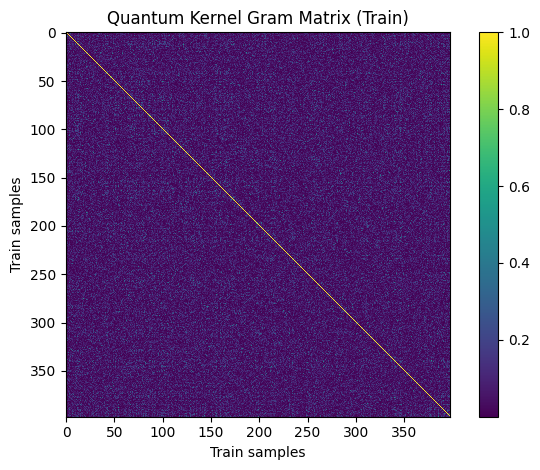

In [ ]:
def take_first_n(X, n):
    if X.shape[1] < n:
        raise ValueError(f"Need at least {n} features; got {X.shape[1]}")
    return X[:, :n]

if QISKIT_OK:
    X_train_q = take_first_n(X_train_t, N_QUBITS)
    X_test_q  = take_first_n(X_test_t, N_QUBITS)

    qkernel = FidelityStatevectorKernel(feature_map=fmap)
    K_train = qkernel.evaluate(X_train_q)
    K_test  = qkernel.evaluate(X_test_q, X_train_q)

    print("K_train:", K_train.shape, "K_test:", K_test.shape)

    plt.figure()
    plt.imshow(K_train, interpolation="nearest")
    plt.title("Quantum Kernel Gram Matrix (Train)")
    plt.xlabel("Train samples")
    plt.ylabel("Train samples")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Qiskit ML not available; install to compute the quantum kernel.")

QSVM -> Acc: 0.5673 | Prec: 0.6051 | Rec: 0.8879


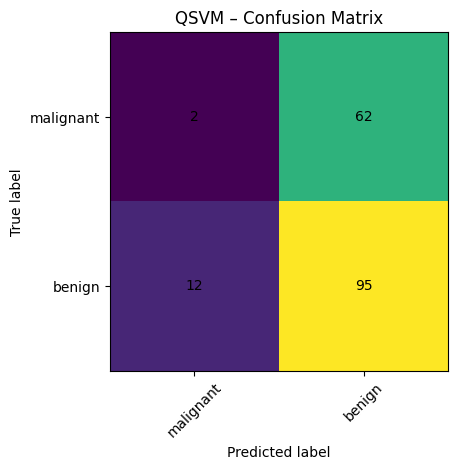

In [ ]:
if QISKIT_OK:
    qsvm = SVC(kernel="precomputed")
    qsvm.fit(K_train, y_train)
    y_q = qsvm.predict(K_test)

    acc_q = accuracy_score(y_test, y_q)
    prec_q = precision_score(y_test, y_q)
    rec_q = recall_score(y_test, y_q)
    cm_q = confusion_matrix(y_test, y_q)

    print("QSVM -> Acc: %.4f | Prec: %.4f | Rec: %.4f" % (acc_q, prec_q, rec_q))
    plot_confusion_matrix(cm_q, "QSVM – Confusion Matrix")
else:
    print("Qiskit ML not available; install to run QSVM.")

In [ ]:
import pandas as pd
rows = [
    {"Model":"SVM Linear","Accuracy":acc_l,"Precision":prec_l,"Recall":rec_l},
    {"Model":"SVM RBF","Accuracy":acc_r,"Precision":prec_r,"Recall":rec_r},
]
if QISKIT_OK:
    rows.append({"Model":"QSVM","Accuracy":acc_q,"Precision":prec_q,"Recall":rec_q})
df = pd.DataFrame(rows)
print(df)

        Model  Accuracy  Precision    Recall
0  SVM Linear  0.941520   0.980198  0.925234
1     SVM RBF  0.959064   0.954545  0.981308
2        QSVM  0.567251   0.605096  0.887850


In [ ]:
A1 = "your answer"
A2 = "your answer"
A3 = "your answer"

def has_any(ans, keywords_list):
    ans = ans.lower()
    return any(all(k in ans for k in ks) for ks in keywords_list)

score = 0
score += int(has_any(A1, [["scale"], ["standard", "range"], ["similar", "range"]]))
score += int(has_any(A2, [["map","quantum","state"], ["circuit","embed"]]))
score += int(has_any(A3, [["similarity","matrix"], ["fidelity","matrix"], ["precomputed","kernel"]]))

print("Score (0-3):", score)
if score == 3:
    print("Great! You’re presentation‑ready 🎉")
else:
    print("Review the notes above and try again 👍")

In [ ]:
!pip install pylatexenc